In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def imshow(image= None):
  """
  Display a BGR image using Matplotlib.

  Converts the input image from OpenCV's BGR color space to RGB
  before displaying it and hides the axis for cleaner visualization.
  """
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

# **watershed algorithem maker-based**

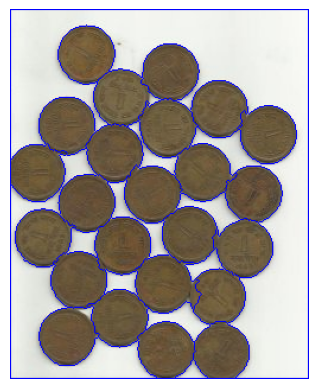

In [10]:
# Load the input image
image = cv.imread("/content/drive/MyDrive/Colab Notebooks/Image/water_coins.jpg")

# Convert image to grayscale for processing
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# Apply Otsu thresholding to separate foreground objects from background
ret, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

# Create a kernel for morphological operations
kernel = np.ones((3, 3), np.uint8)

# Remove small noise using morphological opening
opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel, iterations=2)

# Expand the background region to obtain sure background area
sure_bg = cv.dilate(opening, kernel, iterations=3)

# Compute distance from each foreground pixel to the nearest background pixel
dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)

# Extract sure foreground regions using distance transform thresholding
ret, sure_fg = cv.threshold(
    dist_transform,
    0.7 * dist_transform.max(),
    255,
    0
)

# Convert foreground mask to uint8 format
sure_fg = np.uint8(sure_fg)

# Determine unknown regions between foreground and background
unknown = cv.subtract(sure_bg, sure_fg)

# Label connected foreground components
ret, markers = cv.connectedComponents(sure_fg)

# Shift labels so background is not zero
markers = markers + 1

# Mark unknown regions with zero label
markers[unknown == 255] = 0

# Apply Watershed segmentation
markers = cv.watershed(image, markers)

# Draw watershed boundaries in blue
image[markers == -1] = [255, 0, 0]

# Display final segmented result
imshow(image)